# GFSK Decoding

## NumPy Only Solution

## Performance Profiling and NUMBA JIT Compiler

In [1]:
import time

class Timer(object):
    def __init__(self, name=None, enabled=True):
        self.name = name
        self.enabled = enabled

    def __enter__(self):
        if self.enabled:
            self.tstart = time.time()

    def __exit__(self, type, value, traceback):
        if self.enabled:
            if self.name:
                print('[%s]' % self.name,)
            print('Elapsed: %s' % (time.time() - self.tstart))

In [2]:
import numpy as np

# -----------------------------
# Helpers
# -----------------------------
def read_iq_int16_interleaved(path: str) -> np.ndarray:
    raw = np.fromfile(path, dtype=np.int16)
    if raw.size % 2:
        raw = raw[:-1]
    iq = raw.reshape(-1, 2).astype(np.float32) / 32768.0
    x = iq[:, 0] + 1j * iq[:, 1]
    return x.astype(np.complex64)

def moving_average(x: np.ndarray, n: int) -> np.ndarray:
    # Simple, deterministic MA; same “feel” as GR moving_average_ff
    if n <= 1:
        return x
    kernel = np.ones(n, dtype=np.float32) / n
    return np.convolve(x, kernel, mode="same").astype(np.float32)


# hysteresis_gate is the performance bottleneck 
# => use JIT compiler
# 170 x Speedup compared to Python loop
# def hysteresis_gate(x: np.ndarray, lo: float, hi: float, initial: int = 0) -> np.ndarray:
#     """
#     Returns 0/1 gate with hysteresis:
#       - goes 1 when x >= hi
#       - goes 0 when x <= lo
#       - holds state in between
#     """
#     g = np.zeros_like(x, dtype=np.uint8)
#     state = 1 if initial else 0
#     for i, v in enumerate(x):
#         if state == 0 and v >= hi:
#             state = 1
#         elif state == 1 and v <= lo:
#             state = 0
#         g[i] = state
#     return g

from numba import njit
@njit(nogil=True, cache=True)
def hysteresis_gate(x, lo, hi, initial=0):
    g = np.empty(x.shape[0], dtype=np.uint8)
    state = 1 if initial else 0
    for i in range(x.shape[0]):
        v = x[i]
        if state == 0 and v >= hi:
            state = 1
        elif state == 1 and v <= lo:
            state = 0
        g[i] = state
    return g

def gate_to_bursts(g: np.ndarray) -> list[tuple[int, int]]:
    """
    Convert 0/1 gate to list of (start, end) sample indices, end exclusive.
    """
    # Rising edges: 0->1 ; Falling edges: 1->0
    dg = np.diff(g.astype(np.int8), prepend=g[0])
    starts = np.where(dg == 1)[0]
    ends   = np.where(dg == -1)[0]
    # starts += 500
    # ends -= 400

    # Handle if starts with 1
    if g[0] == 1 and (len(starts) == 0 or starts[0] != 0):
        starts = np.r_[0, starts]

    # Handle if ends with 1
    if g[-1] == 1:
        ends = np.r_[ends, len(g)]

    # Pair up
    n = min(len(starts), len(ends))
    bursts = [(int(starts[i]), int(ends[i])) for i in range(n) if ends[i] > starts[i]]
    return bursts

def design_lowpass_fir(fs: float, cutoff_hz: float, trans_hz: float) -> np.ndarray:
    """
    Simple windowed-sinc FIR lowpass (Hamming).
    Not identical to firdes.low_pass, but close enough for a clean LPF.
    """
    # Rule of thumb for length from transition width:
    # narrower transition -> longer filter
    # Ensure odd length
    N = int(np.ceil(4.0 * fs / max(trans_hz, 1.0)))  # “4” is a decent heuristic
    N = max(N, 33)
    if N % 2 == 0:
        N += 1

    n = np.arange(N) - (N - 1) / 2
    fc = cutoff_hz / fs  # normalized (cycles/sample), 0..0.5
    # ideal LPF impulse response: 2*fc*sinc(2*fc*n)
    h = 2 * fc * np.sinc(2 * fc * n)
    w = np.hamming(N)
    h = (h * w).astype(np.float32)
    h /= np.sum(h)
    return h

def quad_demod(x: np.ndarray, gain: float) -> np.ndarray:
    """
    Quadrature FM demod: gain * angle(x[n]*conj(x[n-1]))
    """
    z = x[1:] * np.conj(x[:-1])
    y = gain * np.angle(z)
    return y.astype(np.float32)

from numba import njit
@njit(nogil=True, cache=True)
def pick_best_phase_and_slice(y: np.ndarray, sps: int) -> np.ndarray:
    """
    Deterministic phase pick: choose k in [0..sps-1] that maximizes “eye opening”
    then slice (y > 0).
    """
    best_k = 0
    best_score = -1e30
    for k in range(sps):
        s = y[k::sps]
        if s.size < 20:
            continue
        s = s - np.median(s)
        score = float(np.mean(np.abs(s)) - 0.2 * np.std(np.abs(s)))
        if score > best_score:
            best_score = score
            best_k = k

    sym = y[best_k::sps]
    bits = (sym > 0).astype(np.uint8)
    return bits

In [3]:
# -----------------------------
# PARAMETERS (match your GR ones)
# -----------------------------
# iq_file = "ls-OFF-4M-p6M.complex32s" 
# iq_file = "ls-OFF-4M-p6M-02.complex32s" 
# iq_file = "ls-OFF-4M-p6M-03.complex32s"
iq_file = "ls-b1-short-press-2p405G-4M-1M.complex32s"
# iq_file = "ls-b1-short-press-2p450G-4M-1M.complex32s"
iq_file = "ls-b1-long-press-2p405G-4M-1M.complex32s"
iq_file = "ls-b1-long-press-2p405G-4M-1M-02.complex32s"

samp_rate = 4_000_000
symbol_rate = 250_000
sps = int(samp_rate / symbol_rate)      # 16

df = 150_000
quad_gain = samp_rate / (2*np.pi*df)

gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 8 #16

lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000  # used only to pick FIR length (roughly)

out_bits_file = "out_bits.bin"

# Burst filtering / cleanup
min_burst_samps = int(0.0005 * samp_rate)  # 0.5 ms minimum burst length (tune)
pad_samps = int(0.0001 * samp_rate)        # 0.1 ms pad around bursts (tune)

# Performance Profiling
profiling_enabled = False

# -----------------------------
# MAIN
# -----------------------------
with Timer("x", profiling_enabled):
    x = read_iq_int16_interleaved(iq_file)
print("Loaded IQ samples:", x.size)

# Pass A: burst detection
with Timer("mag", profiling_enabled):
    mag = np.abs(x).astype(np.float32)
with Timer("ma", profiling_enabled):
    ma = moving_average(mag, smooth_len)
with Timer("gate", profiling_enabled):
    gate = hysteresis_gate(ma, gate_lo, gate_hi, gate_initial)
with Timer("bursts", profiling_enabled):
    bursts = gate_to_bursts(gate)

# cleanup: pad and min length
with Timer("clean", profiling_enabled):
    clean = []
    for a, b in bursts:
        a2 = max(0, a - pad_samps)
        b2 = min(x.size, b + pad_samps)
        if (b2 - a2) >= min_burst_samps:
            clean.append((a2, b2))

print(f"Detected bursts: {len(bursts)}  after cleanup: {len(clean)}")
if clean[:5]:
    print("First bursts (samples):", clean[:5])

# Pass B: per-burst decode
taps = design_lowpass_fir(samp_rate, lpf_cutoff_hz, lpf_trans_hz)

with Timer("all_bits", profiling_enabled):
    all_bits = []
    for i, (a, b) in enumerate(clean):
        xb = x[a:b]
        if xb.size < (sps * 8):
            continue
    
        d = quad_demod(xb, quad_gain)            # length = len(xb)-1
        y = np.convolve(d, taps, mode="same")    # LPF
        bits = pick_best_phase_and_slice(y, sps)
    
        all_bits.append(bits)

out = np.concatenate(all_bits).astype(np.uint8) if all_bits else np.empty(0, np.uint8)
out.tofile(out_bits_file)

print(f"Wrote {out.size} bits to {out_bits_file}")

Loaded IQ samples: 136380416
Detected bursts: 4420  after cleanup: 4419
First bursts (samples): [(2149117, 2154344), (2167192, 2172418), (2185266, 2190492), (2203344, 2208570), (2221418, 2226644)]
Wrote 1444561 bits to out_bits.bin


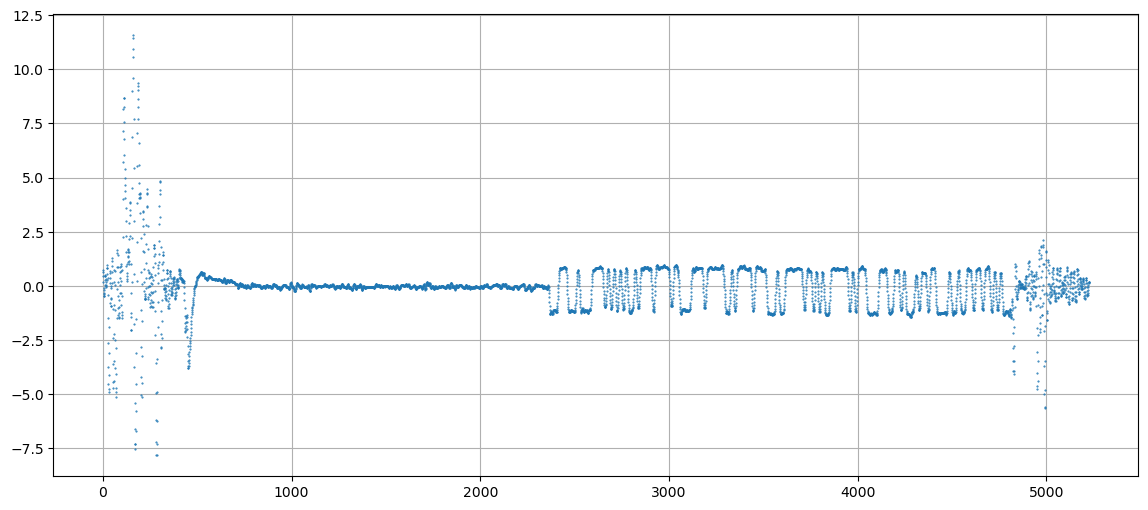

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
# plt.plot(mag[clean[0][0]:clean[0][1]])
# plt.plot(ma[clean[0][0]:clean[0][1]])
# plt.plot(d[clean[0][0]:clean[0][1]])
# plt.plot(0.05*gate[clean[0][0]:clean[0][1]])
plt.plot(y,'.',markersize=1)
# plt.ylim([-10,10])
plt.grid()
plt.show()

In [5]:
out.shape

(1444561,)

In [6]:
# def bits_to_hex_bytewise(bits: str) -> str:
#     hex_bytes = []
#     for i in range(0, len(bits), 8):
#         byte = bits[i:i+8]
#         if len(byte) < 8:
#             byte = byte.ljust(8, "0")  # RIGHT-pad with zeros
#         hex_bytes.append(f"{int(byte, 2):02x}")

#     return "".join(hex_bytes)


In [7]:
def bits_to_hex_bytewise(
    bits: str,
    reverse: bool = False,
    bit_order: str = "msb",   # "msb" or "lsb"
) -> str:
    bits = "".join(bits.split())
    hex_bytes = []

    def normalize_byte(byte: str) -> str:
        if len(byte) < 8:
            byte = byte.ljust(8, "0")  # default right-pad
        if bit_order.lower() == "lsb":
            byte = byte[::-1]          # reverse bits inside byte
        return byte

    if not reverse:
        # left → right (chronological)
        for i in range(0, len(bits), 8):
            byte = bits[i:i+8]
            byte = normalize_byte(byte)
            hex_bytes.append(f"{int(byte, 2):02x}")
    else:
        # right → left
        for i in range(len(bits), 0, -8):
            byte = bits[max(0, i-8):i]
            if len(byte) < 8:
                byte = byte.rjust(8, "0")  # pad on the left in reverse mode
            if bit_order.lower() == "lsb":
                byte = byte[::-1]
            hex_bytes.append(f"{int(byte, 2):02x}")

        hex_bytes.reverse()

    return "".join(hex_bytes)


In [8]:
import numpy as np

arr = out

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110" 
# pattern_str = "1110001" # x 867
# pattern_str = "11100010000111101010101001011110111110" # x 316
# 144 symbols => 18 bytes
# [144 bits]+[101]
# pattern_str = "11100010000111101010101001011110111110110000111101111110010111101111000100111110110000111111000011000011100101001100000100010010010010111000000"
# pattern_str = "111000100001111010101010010111101111101100001111011111100101111101111000100111111011010100111111010111000011100101001100000100010011001001101110101"
# pattern_str = "111000100001111010101010010111101111101100001111011111100101111101111000100111111011010100111111010111000011100101001100000100010011001001101110"
# pattern_str = "1110001000011110101010100101111011111011000011110111111001011111011110001001111110110101001111110101110000111000010011010001000000100110010011101010"
# pattern_str = "11100010000111101010101001011110111110110000111101111110010111110111100010011111101101010011111101011100"

# 2.405 GHZ
# pattern_str = "11100010000111101010101001011110111110110000111101111110010111110111100010011111101101010011111101011100001110000100110100010000001001100100111"
# e21eaa5efb0f7e5f789fb53f5c384d10264e

# 2.450 GHz
# pattern_str = "11100010000111101010101001011110111110110000111101111110010111110111100010011111101101010011111101011100001110011001001011101000011110100111000"
# e21eaa5efb0f7e5f789fb53f5c3992e87a70
pattern_str = "1110001000011110101010100101111011111011000011110111111001011111"

pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)
windows = np.lib.stride_tricks.sliding_window_view(arr, m)
matches = np.all(windows == pattern, axis=1)
indices = np.where(matches)[0]

print(len(indices))
#print(indices)

2478


In [9]:
# pattern_str = "111000100001111010101010010111101111101100001111011111100101111101111000100111111011010100111111010111000011100101001100000100010011001001101110"
 
print(bits_to_hex_bytewise(pattern_str))

e21eaa5efb0f7e5f


In [10]:
len(pattern_str)

64

In [11]:
e21eaa5efb0f7e5f789fb53f5c 384d10264e 0101
e21eaa5efb0f7e5f789fb53f5c 3992e87a70 0101

SyntaxError: invalid decimal literal (3919351915.py, line 1)

In [ ]:
13 bytes - 5 bytes

In [12]:
np.set_printoptions(linewidth=130)
ofs = 13*8 #144
print_len = 20
for i in indices[:10]:
    print(out[i+ofs:i+ofs+print_len])

[0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1]
[0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1]
[0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1]
[0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1]
[0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1]
[0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1]
[0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1]
[0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1]
[0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1]
[0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1]


In [134]:
bits_to_hex_bytewise('0101')

'50'

In [157]:
len(pattern_str)

63

In [205]:
pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
pattern_str = "1110001000011110101010100101111011111011000011110111111001011111" 
# pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
print(len(pattern_str))
print(bits_to_hex_bytewise(pattern_str))
# print(bits_to_hex_bytewise(pattern_str, reverse=True))

64
e21eaa5efb0f7e5f


In [201]:
# hex(int(pattern_str, 2))

In [200]:
# for i in range(int(len(pattern_str)/8)):
#     byte = pattern_str[i%8:i%8+8]
#     # print(pattern_str[i%8:i%8+8])
#     print(bits_to_hex_bytewise(byte))
#     # print(bits_to_hex_bytewise_reverse(byte))

In [223]:
bits_to_hex_bytewise('10100001')

'a1'

In [ ]:
144 bits + 1010 # 0xa0 => 0xaX
144 bits = 18 bytes
[8 bytes] - [5 bytes] - [1 Byte] - [3 bytes] - [1 Byte] + [1010]
[8 bytes] - [5 bytes] - [1 Byte] - [4 bytes]
8*8 + 5*8 + 1*8 + 3*8 + 1*8  = 144

e21eaa5efb0f7e5f789fb53f5c3992e87a70

In [225]:
8*8 + 5*8 + 1*8 + 3*8 + 1*8 

144

In [29]:
np.set_printoptions(linewidth=130)
bit_string = ''.join(map(str, out.tolist()))
ofs = 0 #8*8 + 5*8 + 1*8 + 3*8 + 1*8 
print_len = 18*8
# tag_lengths = np.array([8,5,1,3,1])*2 # length in characters
# tag_lengths = np.array([8,5,1,4])*2 # length in characters
# tag_lengths = np.array([8,5,2,3])*2 # length in characters
tag_lengths = np.array([8,1,4,3,2])*2 # length in characters
cnt = 1
for idx, i in enumerate(indices[:10]):   
    # print(arr[i+ofs:i+ofs+print_len])
    payload = bits_to_hex_bytewise(bit_string[i+ofs:i+ofs+print_len], reverse=False, bit_order='msb')
    # if idx > 0 and payload == payload_prev:
    #     cnt += 1
    #     #print("cnt = {}".format(cnt))
    #     continue
    #cnt += 1    
    p = payload
    t_prev = 0
    for t in tag_lengths:
        # print('range = [{}, {}]'.format(t_prev,t_prev+t))
        # print(t)
        print(f"{p[t_prev:t_prev+t]}"+' ', end='')
        t_prev += t   
    # print(f" [{cnt}]")
    print('')
    payload_prev = payload
    # cnt = 1

e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692 
e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692 
e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692 
e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692 
e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692 
e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692 
e21eaa5efb0f7e5f 78 9fb53f5c 389000 0000 
e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692 
e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692 
e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692 


In [33]:
np.set_printoptions(linewidth=130)
bit_string = ''.join(map(str, out.tolist()))
ofs = 0 #8*8 + 5*8 + 1*8 + 3*8 + 1*8 
print_len = 18*8
# tag_lengths = np.array([8,5,1,3,1])*2 # length in characters
# tag_lengths = np.array([8,5,1,4])*2 # length in characters
# tag_lengths = np.array([8,5,2,3])*2 # length in characters
tag_lengths = np.array([8,1,4,3,2])*2 # length in characters
cnt = 1
for idx, i in enumerate(indices):   
    # print(arr[i+ofs:i+ofs+print_len])
    payload = bits_to_hex_bytewise(bit_string[i+ofs:i+ofs+print_len], reverse=False, bit_order='msb')
    if idx > 0 and payload == payload_prev:
        cnt += 1
        #print("cnt = {}".format(cnt))
        if idx == (len(indices)-1):
            print(f" [{cnt}]")   
        continue
    elif idx > 0:
        print(f" [{cnt}]")   
    p = payload
    t_prev = 0
    for t in tag_lengths:
        # print('range = [{}, {}]'.format(t_prev,t_prev+t))
        # print(t)
        print(f"{p[t_prev:t_prev+t]}"+' ', end='')
        t_prev += t   
    
    # print('')
    payload_prev = payload
    cnt = 1
        
        
#print("\n"+bits_to_hex_bytewise(bit_string[i+ofs:i+ofs+print_len], bit_order='msb'))
#print(payload)

e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692  [6]
e21eaa5efb0f7e5f 78 9fb53f5c 389000 0000  [1]
e21eaa5efb0f7e5f 78 9fb53f5c 39b8c5 6692  [33]
e21eaa5efb0f7e5f 78 9fb53f5c 38b9c4 72b2  [31]
e21eaa5efb0f7e5f 18 0c000000 000000 0000  [1]
e21eaa5efb0f7e5f 78 9fb53f5c 38b9c4 72b2  [8]
e21eaa5efb0f7e5f 78 9fb53f5c 397834 8ff8  [40]
e21eaa5efb0f7e5f 78 9fb53f5c 387935 9bd8  [29]
e21eaa5efb0f7e5f 78 9fb53f5c 39f8b4 05e8  [40]
e21eaa5efb0f7e5f 78 9fb53f5c 38f9b5 11c8  [40]
e21eaa5efb0f7e5f 78 9fb53f5c 390875 df44  [40]
e21eaa5efb0f7e5f 78 9fb53f5c 380974 cb64  [40]
e21eaa5efb0f7e5f 78 9fb53f5c 3988f5 5554  [40]
e21eaa5efb0f7e5f 78 9fb53f5c 3889f4 4174  [40]
e21eaa5efb0f7e5f 78 9fb53f5c 394815 be2e  [40]
e21eaa5efb0f7e5f f8 9fb53f5c 3dc850 9c96  [40]
e21eaa5efb0f7e5f 38 9fb53f5c 3d2828 78ea  [40]
e21eaa5efb0f7e5f b8 9fb53f5c 3da869 c616  [40]
e21eaa5efb0f7e5f 58 9fb53f5c 3d6808 dcfc  [40]
e21eaa5efb0f7e5f d8 9fb53f5c 3be84f b066  [40]
e21eaa5efb0f7e5f 18 9fb53f5c 3b143f 930c  [40]
e21eaa5efb0f7e5f 

In [ ]:
e21eaa5efb0f7e5f789fb53f5c394c11326e

In [14]:
bit_string =  "111000100001111010101010010111101111101100001111011111100101111101111000100111111011010100111111010111000011100101001100000100010011001001101110000000"
bits_to_hex_bytewise(bit_string)

'e21eaa5efb0f7e5f789fb53f5c394c11326e00'

In [10]:
def generate_series():
    def bitrev5(n):
        return int(f"{n:05b}"[::-1], 2)

    seq = []
    base = [(bitrev5(n) ^ 0x0E) & 0x1F for n in range(32)]
    base = base[16:] + base[:16]   # rotate so it starts at 0x98

    for i, v in enumerate(base):
        if i < 25:
            seq.append(v << 3)
        else:
            seq.append((v << 3) | 0x04)

    return seq


In [11]:
print([f"{x:02x}" for x in generate_series()])

['78', 'f8', '38', 'b8', '58', 'd8', '18', '98', '68', 'e8', '28', 'a8', '48', 'c8', '08', '88', '70', 'f0', '30', 'b0', '50', 'd0', '10', '90', '60', 'e4', '24', 'a4', '44', 'c4', '04', '84']


In [28]:
def bitrev5(n):
        return int(f"{n:05b}"[::-1], 2)

seq = []
base = [(bitrev5(n) ^ 0x0E) & 0x1F for n in range(32)]

In [29]:
base

[14,
 30,
 6,
 22,
 10,
 26,
 2,
 18,
 12,
 28,
 4,
 20,
 8,
 24,
 0,
 16,
 15,
 31,
 7,
 23,
 11,
 27,
 3,
 19,
 13,
 29,
 5,
 21,
 9,
 25,
 1,
 17]

In [316]:
from binascii import unhexlify

msgs = [
("e21eaa5efb0f7e5f","789fb53f5c","3992e8","7a70"),
("e21eaa5efb0f7e5f","789fb53f5c","3893e9","6e50"),
("e21eaa5efb0f7e5f","789fb53f5c","395208","910a"),
("e21eaa5efb0f7e5f","789fb53f5c","385309","852a"),
("e21eaa5efb0f7e5f","789fb53f5c","39d288","1b1a"),
("e21eaa5efb0f7e5f","789fb53f5c","38d389","0f3a"),
("e21eaa5efb0f7e5f","789fb53f5c","393248","d2e4"),
("e21eaa5efb0f7e5f","789fb53f5c","383349","c6c4"),
("e21eaa5efb0f7e5f","789fb53f5c","383349","c6c4"),
("e21eaa5efb0f7e5f","789fb53f5c","39b2c8","58f4"),
("e21eaa5efb0f7e5f","789fb53f5c","38b3c9","4cd4"),
]

def reflect_bits(x, width):
    r=0
    for i in range(width):
        if (x >> i) & 1:
            r |= 1 << (width-1-i)
    return r

def crc16_noref(data, poly, init, xorout):
    crc = init & 0xFFFF
    for b in data:
        crc ^= (b << 8) & 0xFFFF
        for _ in range(8):
            crc = ((crc << 1) ^ poly) & 0xFFFF if (crc & 0x8000) else (crc << 1) & 0xFFFF
    return (crc ^ xorout) & 0xFFFF

def crc16_ref(data, poly, init, xorout):
    poly_r = reflect_bits(poly, 16)
    crc = init & 0xFFFF
    for b in data:
        crc ^= b
        for _ in range(8):
            crc = (crc >> 1) ^ poly_r if (crc & 1) else (crc >> 1)
        crc &= 0xFFFF
    return (crc ^ xorout) & 0xFFFF

variants = {
    "CCITT-FALSE": ("noref", 0x1021, 0xFFFF, 0x0000),
    "XMODEM":      ("noref", 0x1021, 0x0000, 0x0000),
    "ARC":         ("ref",   0x8005, 0x0000, 0x0000),
    "MODBUS":      ("ref",   0x8005, 0xFFFF, 0x0000),
    "X25":         ("ref",   0x1021, 0xFFFF, 0xFFFF),
}

for a,b,c,given in msgs:
    data = unhexlify(a+b+c)          # <-- change this if you want different coverage
    exp  = int(given, 16)
    exp_sw = ((exp >> 8) | ((exp & 0xFF) << 8)) & 0xFFFF

    print((a+b+c).upper(), " given=", f"{exp:04X}")
    for name,(mode,poly,init,xorout) in variants.items():
        got = crc16_ref(data,poly,init,xorout) if mode=="ref" else crc16_noref(data,poly,init,xorout)
        ok = (got == exp) or (got == exp_sw)
        print(f"  {name:11s} got={got:04X}  match={ok}")
    print()


E21EAA5EFB0F7E5F789FB53F5C3992E8  given= 7A70
  CCITT-FALSE got=8B41  match=False
  XMODEM      got=E14B  match=False
  ARC         got=EEAA  match=False
  MODBUS      got=1E14  match=False
  X25         got=B81E  match=False

E21EAA5EFB0F7E5F789FB53F5C3893E9  given= 6E50
  CCITT-FALSE got=9F61  match=False
  XMODEM      got=F56B  match=False
  ARC         got=7E3B  match=False
  MODBUS      got=8E85  match=False
  X25         got=EA93  match=False

E21EAA5EFB0F7E5F789FB53F5C395208  given= 910A
  CCITT-FALSE got=603B  match=False
  XMODEM      got=0A31  match=False
  ARC         got=66FB  match=False
  MODBUS      got=9645  match=False
  X25         got=95BA  match=False

E21EAA5EFB0F7E5F789FB53F5C385309  given= 852A
  CCITT-FALSE got=741B  match=False
  XMODEM      got=1E11  match=False
  ARC         got=F66A  match=False
  MODBUS      got=06D4  match=False
  X25         got=C737  match=False

E21EAA5EFB0F7E5F789FB53F5C39D288  given= 1B1A
  CCITT-FALSE got=EA2B  match=False
  XMODEM  